# K-Means Clustering on Facebook Post Data
Bộ dữ liệu này chứa thông tin về các bài đăng trên Facebook của một trang truyền thông, bao gồm loại bài đăng, thời gian đăng, và số lượng tương tác (like, comment, share, các biểu cảm cảm xúc như love, wow, haha, sad, angry). Dữ liệu này có thể được sử dụng để phân tích hành vi người dùng, hoặc phân cụm các bài đăng dựa trên mức độ tương tác.

## Mục tiêu
- Áp dụng thuật toán K-Means để phân cụm các bài đăng Facebook dựa trên mức độ tương tác.
- Xác định những nhóm bài đăng có đặc điểm tương đồng để đưa ra chiến lược nội dung phù hợp.
* [**Bộ dữ liệu**](https://drive.google.com/file/d/1qCMHidzHkqtW6ncHK9S1REZWI2_CGehL/view?usp=drive_link)

## Bước 1: Khám Phá Bộ Dữ Liệu

Hãy thực hiện EDA để khám phá và xử lý bộ dữ liệu

In [1]:
## CODE CỦA BẠN ##
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as snb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from datetime import datetime
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

In [2]:
social_network_df = pd.read_csv('Live.csv')
social_network_df

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,1050855161656896_1061863470556065,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0,NaN,NaN,NaN,NaN
7046,1050855161656896_1061334757275603,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0,NaN,NaN,NaN,NaN
7047,1050855161656896_1060126464063099,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN
7048,1050855161656896_1058663487542730,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0,NaN,NaN,NaN,NaN


In [3]:
scalled_cols = ['num_reactions','num_comments','num_shares',
    'num_likes','num_loves','num_wows',
    'num_hahas','num_sads','num_angrys'
]

social_network_eda_df = social_network_df[scalled_cols]

social_network_eda_df['status_type'] = social_network_df['status_type']
social_network_eda_df


C:\Users\Ryan\AppData\Local\Temp\ipykernel_3032\1398030966.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  social_network_eda_df['status_type'] = social_network_df['status_type']


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type
0,529,512,262,432,92,3,1,1,0,video
1,150,0,0,150,0,0,0,0,0,photo
2,227,236,57,204,21,1,1,0,0,video
3,111,0,0,111,0,0,0,0,0,photo
4,213,0,0,204,9,0,0,0,0,photo
...,...,...,...,...,...,...,...,...,...,...
7045,89,0,0,89,0,0,0,0,0,photo
7046,16,0,0,14,1,0,1,0,0,photo
7047,2,0,0,1,1,0,0,0,0,photo
7048,351,12,22,349,2,0,0,0,0,photo


In [4]:
encoder = LabelEncoder()

social_network_eda_df['status_type'] = encoder.fit_transform(social_network_eda_df['status_type'])
social_network_eda_df

C:\Users\Ryan\AppData\Local\Temp\ipykernel_3032\4101804225.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  social_network_eda_df['status_type'] = encoder.fit_transform(social_network_eda_df['status_type'])


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type
0,529,512,262,432,92,3,1,1,0,3
1,150,0,0,150,0,0,0,0,0,1
2,227,236,57,204,21,1,1,0,0,3
3,111,0,0,111,0,0,0,0,0,1
4,213,0,0,204,9,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
7045,89,0,0,89,0,0,0,0,0,1
7046,16,0,0,14,1,0,1,0,0,1
7047,2,0,0,1,1,0,0,0,0,1
7048,351,12,22,349,2,0,0,0,0,1


In [5]:
print(f'Status type range: {social_network_eda_df['status_type'].min()} - {social_network_eda_df['status_type'].max()}')
print(f'Num of reaction range: {social_network_eda_df['num_reactions'].min()} - {social_network_eda_df['num_reactions'].max()}')
print(f'Num of comment range: {social_network_eda_df['num_comments'].min()} - {social_network_eda_df['num_comments'].max()}')
print(f'Num of share range: {social_network_eda_df['num_shares'].min()} - {social_network_eda_df['num_shares'].max()}')
print(f'Num of like range: {social_network_eda_df['num_likes'].min()} - {social_network_eda_df['num_likes'].max()}')
print(f'Num of love range: {social_network_eda_df['num_loves'].min()} - {social_network_eda_df['num_loves'].max()}')
print(f'Num of wow range: {social_network_eda_df['num_wows'].min()} - {social_network_eda_df['num_wows'].max()}')
print(f'Num of haha range: {social_network_eda_df['num_hahas'].min()} - {social_network_eda_df['num_hahas'].max()}')
print(f'Num of sad range: {social_network_eda_df['num_sads'].min()} - {social_network_eda_df['num_sads'].max()}')
print(f'Num of angry range: {social_network_eda_df['num_angrys'].min()} - {social_network_eda_df['num_angrys'].max()}')

Status type range: 0 - 3
Num of reaction range: 0 - 4710
Num of comment range: 0 - 20990
Num of share range: 0 - 3424
Num of like range: 0 - 4710
Num of love range: 0 - 657
Num of wow range: 0 - 278
Num of haha range: 0 - 157
Num of sad range: 0 - 51
Num of angry range: 0 - 31


## Bước 2: Chuẩn hóa dữ liệu



In [6]:
### CODE CỦA BẠN ##
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# Log transform
social_network_scaled_df = social_network_eda_df.copy()
social_network_scaled_df[scalled_cols] = np.log1p(
    social_network_scaled_df[scalled_cols]
)

# Scale numeric columns
scaler = RobustScaler()
scaled_array = scaler.fit_transform(
    social_network_scaled_df[scalled_cols]
)

# Convert to DataFrame
social_network_scaled_df = pd.DataFrame(
    scaled_array,
    columns=scalled_cols,
    index=social_network_scaled_df.index
)

# One-hot encode status_type
status_dummies = pd.get_dummies(
    social_network_eda_df['status_type'],
    prefix='status',
    dtype=int
)

# Concat
social_network_scaled_df = pd.concat(
    [social_network_scaled_df, status_dummies],
    axis=1
)

social_network_scaled_df.head()



,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_0,status_1,status_2,status_3
0,0.866978,1.457130,3.462174,0.853975,3.269579,1.386294,0.693147,0.693147,0.0,0,0,0,1
1,0.365392,-0.506422,0.000000,0.402627,0.000000,0.000000,0.000000,0.000000,0.0,0,1,0,0
2,0.530004,1.214146,2.522895,0.533615,2.229716,0.693147,0.693147,0.000000,0.0,0,0,0,1
3,0.246035,-0.506422,0.000000,0.274616,0.000000,0.000000,0.000000,0.000000,0.0,0,1,0,0
4,0.504689,-0.506422,0.000000,0.533615,1.660964,0.000000,0.000000,0.000000,0.0,0,1,0,0


In [7]:
print(f'Num of reaction range: {social_network_scaled_df['num_reactions'].min()} - {social_network_scaled_df['num_reactions'].max()}')
print(f'Num of comment range: {social_network_scaled_df['num_comments'].min()} - {social_network_scaled_df['num_comments'].max()}')
print(f'Num of share range: {social_network_scaled_df['num_shares'].min()} - {social_network_scaled_df['num_shares'].max()}')
print(f'Num of like range: {social_network_scaled_df['num_likes'].min()} - {social_network_scaled_df['num_likes'].max()}')
print(f'Num of love range: {social_network_scaled_df['num_loves'].min()} - {social_network_scaled_df['num_loves'].max()}')
print(f'Num of wow range: {social_network_scaled_df['num_wows'].min()} - {social_network_scaled_df['num_wows'].max()}')
print(f'Num of haha range: {social_network_scaled_df['num_hahas'].min()} - {social_network_scaled_df['num_hahas'].max()}')
print(f'Num of sad range: {social_network_scaled_df['num_sads'].min()} - {social_network_scaled_df['num_sads'].max()}')
print(f'Num of angry range: {social_network_scaled_df['num_angrys'].min()} - {social_network_scaled_df['num_angrys'].max()}')

Num of reaction range: -1.638909308476166 - 1.7397527993686053
Num of comment range: -0.5064224831767222 - 2.625006241655305
Num of share range: 0.0 - 5.056956026583956
Num of like range: -1.7469965377929835 - 1.876635382796307
Num of love range: 0.0 - 4.680971886867621
Num of wow range: 0.0 - 5.631211781821365
Num of haha range: 0.0 - 5.062595033026967
Num of sad range: 0.0 - 3.9512437185814275
Num of angry range: 0.0 - 3.4657359027997265


## Bước 3: Xây dựng mô hình KMeans

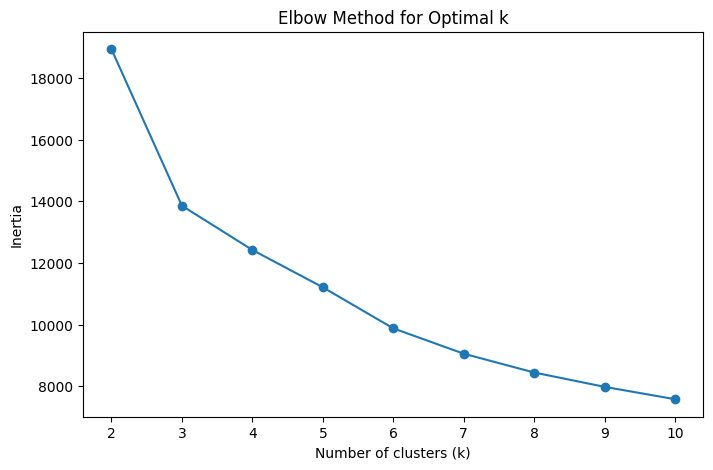

In [8]:
### CODE CỦA BẠN ##

inertia_values = []
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(social_network_scaled_df)
    inertia_values.append(kmeans.inertia_)
# Vẽ đồ thị Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.show()

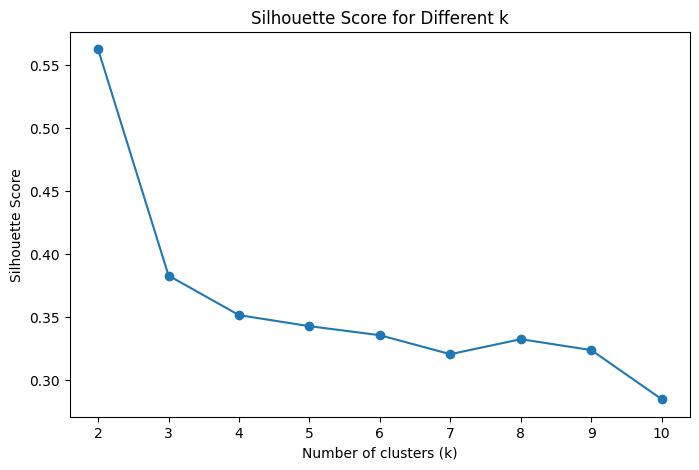

In [9]:
# Tính silhouette score
from sklearn.metrics import silhouette_score
list_k = range(2, 11)
silhouette_scores = []

for k in list_k:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(social_network_scaled_df)

    sil_avg = silhouette_score(social_network_scaled_df, model.labels_)
    silhouette_scores.append(sil_avg)

# Vẽ đồ thị silhouette score
plt.figure(figsize=(8, 5))
plt.plot(list_k, silhouette_scores, marker='o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list_k)
plt.show()

In [ ]:
model = KMeans(n_clusters=10, random_state=42)
model.fit(social_network_scaled_df)
inertia = model.inertia_ # trung bình khoảng cách từ các điểm đến các tâm.
print(f'Inertia: {inertia}')

Inertia: 7579.762380949856


In [11]:
centroids = model.cluster_centers_
print(centroids)

[[ 4.53047553e-01  1.91948582e-01  3.16350296e-01  4.80173543e-01
   1.12290867e+00  6.52157367e-01  1.14022458e-01  1.09360955e-01
   2.61980172e-02  1.48809524e-03  8.97321429e-01  5.95238095e-02
   4.16666667e-02]
 [ 1.02418073e+00  1.94319036e+00  3.76349024e+00  9.92392088e-01
   3.53555986e+00  2.26104794e+00  2.18954436e+00  9.78951754e-01
   7.43399802e-01  1.04083409e-17  9.95024876e-03  9.02056208e-17
   9.90049751e-01]
 [ 4.94928701e-01  1.53559103e+00  3.08982884e+00  4.01146596e-01
   2.78982819e+00  5.94565752e-01  9.00537351e-01  2.77997279e-01
   2.13167941e-01  1.73472348e-17  3.61881785e-03  1.20627262e-03
   9.95174910e-01]
 [-6.09846908e-01 -3.38355943e-01  7.92298370e-02 -6.48015766e-01
   4.30891148e-02  1.67323215e-02  2.99092635e-03  7.91471080e-03
   8.68089489e-04  4.85436893e-03  9.92988134e-01  2.15749730e-03
  -3.66373598e-15]
 [ 1.11627190e+00  3.27041854e-01  4.63379116e-01  1.20786694e+00
   8.47502594e-03  1.09076667e-02  4.31419407e-03  9.71396520e-03


In [12]:
social_network_eda_df['Cluster'] =  model.labels_
social_network_eda_df

C:\Users\Ryan\AppData\Local\Temp\ipykernel_3032\3590251163.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  social_network_eda_df['Cluster'] =  model.labels_


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
0,529,512,262,432,92,3,1,1,0,3,2
1,150,0,0,150,0,0,0,0,0,1,8
2,227,236,57,204,21,1,1,0,0,3,2
3,111,0,0,111,0,0,0,0,0,1,8
4,213,0,0,204,9,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
7045,89,0,0,89,0,0,0,0,0,1,8
7046,16,0,0,14,1,0,1,0,0,1,3
7047,2,0,0,1,1,0,0,0,0,1,3
7048,351,12,22,349,2,0,0,0,0,1,6


In [13]:
social_network_eda_df_cluster_0 = social_network_eda_df[social_network_eda_df['Cluster'] == 0]
social_network_eda_df_cluster_0

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
4,213,0,0,204,9,0,0,0,0,1,0
5,217,6,0,211,5,1,0,0,0,1,0
8,203,1,0,198,5,0,0,0,0,1,0
9,170,9,1,167,3,0,0,0,0,1,0
10,210,2,3,202,7,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6999,203,0,4,200,1,1,1,0,0,1,0
7000,266,7,3,265,1,0,0,0,0,1,0
7003,185,6,0,181,2,2,0,0,0,1,0
7004,281,6,4,277,2,1,1,0,0,1,0


In [14]:
social_network_eda_df_cluster_1 = social_network_eda_df[social_network_eda_df['Cluster'] == 1]
social_network_eda_df_cluster_1

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
6,503,614,72,418,70,10,2,0,3,3,1
99,1493,1979,753,1333,139,9,3,8,1,3,1
166,4410,633,257,4315,73,17,5,0,0,1,1
208,734,996,73,601,116,11,6,0,0,3,1
281,498,254,17,408,77,5,6,1,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...
6861,391,6407,174,340,36,4,9,2,0,3,1
6865,426,4637,187,356,44,12,6,3,5,3,1
6906,407,4225,179,318,55,4,26,4,0,3,1
6977,253,4432,167,209,29,5,5,5,0,3,1


In [15]:
social_network_eda_df_cluster_2 = social_network_eda_df[social_network_eda_df['Cluster'] == 2]
social_network_eda_df_cluster_2

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
0,529,512,262,432,92,3,1,1,0,3,2
2,227,236,57,204,21,1,1,0,0,3,2
7,295,453,53,260,32,1,1,0,1,3,2
15,332,100,30,303,23,1,5,0,0,3,2
16,135,256,79,117,18,0,0,0,0,3,2
...,...,...,...,...,...,...,...,...,...,...,...
6955,266,5000,153,234,27,2,1,1,1,3,2
6959,181,2641,131,154,21,4,2,0,0,3,2
6962,127,2303,109,106,19,2,0,0,0,3,2
6964,211,4487,135,186,22,1,0,1,1,3,2


In [16]:
social_network_eda_df_cluster_3 = social_network_eda_df[social_network_eda_df['Cluster'] == 3]
social_network_eda_df_cluster_3

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
85,14,3,0,12,2,0,0,0,0,1,3
102,19,8,0,18,0,0,1,0,0,1,3
132,15,11,0,15,0,0,0,0,0,1,3
133,16,12,0,16,0,0,0,0,0,1,3
136,8,8,0,8,0,0,0,0,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...
7041,9,0,0,7,2,0,0,0,0,1,3
7042,4,0,0,4,0,0,0,0,0,1,3
7046,16,0,0,14,1,0,1,0,0,1,3
7047,2,0,0,1,1,0,0,0,0,1,3


In [18]:
social_network_eda_df_cluster_4 = social_network_eda_df[social_network_eda_df['Cluster'] == 4]
social_network_eda_df_cluster_4

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
744,264,27,3,264,0,0,0,0,0,1,4
915,279,18,2,279,0,0,0,0,0,1,4
929,421,3,0,421,0,0,0,0,0,1,4
933,263,19,2,263,0,0,0,0,0,1,4
939,355,9,0,355,0,0,0,0,0,1,4
...,...,...,...,...,...,...,...,...,...,...,...
4705,265,82,0,256,1,0,0,8,0,2,4
4706,329,46,7,329,0,0,0,0,0,1,4
5485,552,0,3,551,1,0,0,0,0,1,4
6272,1918,1,10,1917,0,1,0,0,0,1,4


In [20]:
social_network_eda_df_cluster_5 = social_network_eda_df[social_network_eda_df['Cluster'] == 5]
social_network_eda_df_cluster_5

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
314,7,5,0,7,0,0,0,0,0,3,5
699,0,0,1,0,0,0,0,0,0,1,5
715,0,0,1,0,0,0,0,0,0,1,5
925,6,0,0,6,0,0,0,0,0,0,5
1321,0,0,0,0,0,0,0,0,0,1,5
...,...,...,...,...,...,...,...,...,...,...,...
6982,0,0,0,0,0,0,0,0,0,1,5
6983,6,0,0,6,0,0,0,0,0,2,5
6991,6,0,1,6,0,0,0,0,0,2,5
7016,5,0,0,5,0,0,0,0,0,2,5


In [21]:
social_network_eda_df_cluster_6 = social_network_eda_df[social_network_eda_df['Cluster'] == 6]
social_network_eda_df_cluster_6

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
26,75,36,14,70,5,0,0,0,0,3,6
27,90,78,9,85,5,0,0,0,0,3,6
36,128,137,26,110,16,2,0,0,0,3,6
37,84,15,13,78,5,1,0,0,0,1,6
40,90,72,23,79,10,1,0,0,0,3,6
...,...,...,...,...,...,...,...,...,...,...,...
7017,211,9,10,211,0,0,0,0,0,1,6
7020,256,24,10,256,0,0,0,0,0,1,6
7023,230,23,14,222,8,0,0,0,0,1,6
7040,93,26,34,90,3,0,0,0,0,1,6


In [22]:
social_network_eda_df_cluster_7 = social_network_eda_df[social_network_eda_df['Cluster'] == 7]
social_network_eda_df_cluster_7

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
23,18,0,0,18,0,0,0,0,0,3,7
25,37,0,1,37,0,0,0,0,0,3,7
31,45,14,0,40,5,0,0,0,0,3,7
70,57,0,0,56,1,0,0,0,0,3,7
75,35,1,0,35,0,0,0,0,0,3,7
...,...,...,...,...,...,...,...,...,...,...,...
6963,27,8,0,27,0,0,0,0,0,2,7
6966,21,2,2,21,0,0,0,0,0,2,7
6970,13,0,0,12,1,0,0,0,0,2,7
6987,239,2,4,238,1,0,0,0,0,2,7


In [23]:
social_network_eda_df_cluster_8 = social_network_eda_df[social_network_eda_df['Cluster'] == 8]
social_network_eda_df_cluster_8

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
1,150,0,0,150,0,0,0,0,0,1,8
3,111,0,0,111,0,0,0,0,0,1,8
22,98,0,0,96,0,2,0,0,0,1,8
24,102,0,0,100,0,2,0,0,0,1,8
50,77,11,3,75,2,0,0,0,0,1,8
...,...,...,...,...,...,...,...,...,...,...,...
7031,50,0,0,50,0,0,0,0,0,1,8
7036,236,0,5,235,0,1,0,0,0,1,8
7043,196,2,3,195,1,0,0,0,0,1,8
7044,86,0,0,86,0,0,0,0,0,1,8


In [24]:
social_network_eda_df_cluster_9 = social_network_eda_df[social_network_eda_df['Cluster'] == 9]
social_network_eda_df_cluster_9

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type,Cluster
62,517,32,1,484,26,7,0,0,0,1,9
93,737,18,0,697,31,9,0,0,0,1,9
96,266,25,0,250,11,5,0,0,0,1,9
111,203,18,11,190,7,6,0,0,0,1,9
112,1005,25,1,979,16,9,1,0,0,1,9
...,...,...,...,...,...,...,...,...,...,...,...
6845,122,181,10,113,6,3,0,0,0,1,9
6852,251,266,29,238,6,7,0,0,0,1,9
6855,89,22,7,77,7,5,0,0,0,1,9
6990,154,43,6,147,4,3,0,0,0,1,9


In [30]:
print(type(centroids)) # numpy.ndarray
print(centroids.shape)
print(centroids[0])

<class 'numpy.ndarray'>
(10, 13)
[0.45304755 0.19194858 0.3163503  0.48017354 1.12290867 0.65215737
 0.11402246 0.10936096 0.02619802 0.0014881  0.89732143 0.05952381
 0.04166667]
